# Phase 1 — Data Collection & Preprocessing
### 3D Container Loading Optimizer
This notebook covers:
- Loading and cleaning the collected box dataset
- Normalizing units and handling inconsistencies
- Defining core data structures (Box, Container)
- Exploratory Data Analysis (EDA)
- Preparing data for the optimization algorithms

## 1. Importing the libraries needed for the preprocessing


In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from dataclasses import dataclass, field
from typing import List, Optional, Tuple

sns.set_theme(style='whitegrid')
print('All imports OK ✅')

All imports OK ✅


## 2. Load Dataset

In [2]:
df = pd.read_csv('boxes_120(generated+local).csv')
print(f'Dataset loaded: {len(df)} boxes')
df.head(10)

Dataset loaded: 120 boxes


,id,length,width,height,weight_kg,fragile
0,1,62.0,17.0,60.0,0.020,True
1,2,15.0,12.0,6.0,0.015,True
2,3,31.0,25.0,9.0,2.000,True
3,4,61.0,43.0,8.0,0.500,True
4,5,58.0,39.0,38.0,8.000,True
5,6,34.0,34.0,53.0,20.000,True
6,7,33.0,33.0,24.0,10.000,True
7,8,16.0,16.0,5.0,0.400,True
8,9,15.0,15.0,7.0,0.005,True
9,10,35.0,26.0,35.0,8.000,True


## 3. Data Cleaning & Validation

In [3]:
# --- Check for missing values ---
print('Missing values per column:')
print(df.isnull().sum())

# --- Ensure correct types ---
df['fragile'] = df['fragile'].astype(bool)
for col in ['length', 'width', 'height', 'weight_kg']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# --- Drop rows with invalid dimensions ---
before = len(df)
df.dropna(subset=['length', 'width', 'height', 'weight_kg'], inplace=True)
df = df[(df['length'] > 0) & (df['width'] > 0) & (df['height'] > 0) & (df['weight_kg'] >= 0)]
df.reset_index(drop=True, inplace=True)
print(f'\nRows after cleaning: {len(df)} (removed {before - len(df)} invalid rows)')

Missing values per column:
id           0
length       0
width        0
height       0
weight_kg    0
fragile      0
dtype: int64

Rows after cleaning: 120 (removed 0 invalid rows)


## 4. Feature Engineering

In [4]:
# --- Volume in cm³ ---
df['volume_cm3'] = df['length'] * df['width'] * df['height']

# --- Density (kg / cm³) ---
df['density'] = df['weight_kg'] / df['volume_cm3']

# --- Size category ---
def categorize_size(vol):
    if vol < 1000:
        return 'Small'
    elif vol < 10000:
        return 'Medium'
    else:
        return 'Large'

df['size_category'] = df['volume_cm3'].apply(categorize_size)

print('Feature engineering done ✅')
df[['id','length','width','height','weight_kg','volume_cm3','density','size_category','fragile']].head(10)

Feature engineering done ✅


,id,length,width,height,weight_kg,volume_cm3,density,size_category,fragile
0,1,62.0,17.0,60.0,0.020,63240.0,3.162555e-07,Large,True
1,2,15.0,12.0,6.0,0.015,1080.0,1.388889e-05,Medium,True
2,3,31.0,25.0,9.0,2.000,6975.0,2.867384e-04,Medium,True
3,4,61.0,43.0,8.0,0.500,20984.0,2.382768e-05,Large,True
4,5,58.0,39.0,38.0,8.000,85956.0,9.307087e-05,Large,True
5,6,34.0,34.0,53.0,20.000,61268.0,3.264347e-04,Large,True
6,7,33.0,33.0,24.0,10.000,26136.0,3.826140e-04,Large,True
7,8,16.0,16.0,5.0,0.400,1280.0,3.125000e-04,Medium,True
8,9,15.0,15.0,7.0,0.005,1575.0,3.174603e-06,Medium,True
9,10,35.0,26.0,35.0,8.000,31850.0,2.511774e-04,Large,True


## 5. Core Data Structures

In [5]:
@dataclass
class Box:
    """Represents a single box to be packed."""
    id: int
    length: float
    width: float
    height: float
    weight_kg: float
    fragile: bool = False
    # Position inside container (set during packing)
    x: float = 0.0
    y: float = 0.0
    z: float = 0.0
    placed: bool = False

    @property
    def volume(self) -> float:
        return self.length * self.width * self.height

    def get_dimensions(self) -> Tuple[float, float, float]:
        return (self.length, self.width, self.height)

    def get_orientations(self) -> List[Tuple[float, float, float]]:
        """
        Returns all valid orientations (L, W, H permutations).
        Fragile boxes cannot be flipped upside down:
        height must remain as the vertical axis.
        """
        l, w, h = self.length, self.width, self.height
        if self.fragile:
            # Only rotate in the horizontal plane — height stays fixed
            return [
                (l, w, h),
                (w, l, h),
            ]
        else:
            # All 6 orientations allowed
            return [
                (l, w, h), (l, h, w),
                (w, l, h), (w, h, l),
                (h, l, w), (h, w, l),
            ]

    def __repr__(self):
        return (f'Box(id={self.id}, {self.length}x{self.width}x{self.height}cm, '
                f'{self.weight_kg}kg, fragile={self.fragile})')


@dataclass
class Container:
    """
    Standard ISO 20ft shipping container.
    Internal dimensions (cm): 589 x 235 x 239
    """
    length: float = 589.0   # cm
    width: float  = 235.0   # cm
    height: float = 239.0   # cm

    @property
    def volume(self) -> float:
        return self.length * self.width * self.height

    def can_fit(self, box: Box, x: float, y: float, z: float,
                orientation: Tuple[float,float,float]) -> bool:
        """Check if a box fits at position (x,y,z) with given orientation."""
        bl, bw, bh = orientation
        return (
            x + bl <= self.length and
            y + bw <= self.width  and
            z + bh <= self.height
        )

    def __repr__(self):
        return (f'Container({self.length}x{self.width}x{self.height}cm, '
                f'volume={self.volume/1e6:.2f}m³)')


# --- Instantiate container ---
container = Container()
print(container)

# --- Build list of Box objects from dataframe ---
boxes = [
    Box(
        id=int(row['id']),
        length=row['length'],
        width=row['width'],
        height=row['height'],
        weight_kg=row['weight_kg'],
        fragile=bool(row['fragile'])
    )
    for _, row in df.iterrows()
]

print(f'\nBuilt {len(boxes)} Box objects')
print('Sample:', boxes[:3])

Container(589.0x235.0x239.0cm, volume=33.08m³)

Built 120 Box objects
Sample: [Box(id=1, 62.0x17.0x60.0cm, 0.02kg, fragile=True), Box(id=2, 15.0x12.0x6.0cm, 0.015kg, fragile=True), Box(id=3, 31.0x25.0x9.0cm, 2.0kg, fragile=True)]


## 6. Exploratory Data Analysis (EDA)

In [6]:
print('=== Dataset Summary ===')
print(df[['length','width','height','weight_kg','volume_cm3']].describe().round(2))
print(f'\nFragile boxes : {df["fragile"].sum()} / {len(df)}')
print(f'Size breakdown:\n{df["size_category"].value_counts()}')

=== Dataset Summary ===
       length   width  height  weight_kg  volume_cm3
count  120.00  120.00  120.00     120.00      120.00
mean    57.25   38.79   39.96      16.32    96564.82
std     32.09   19.02   23.23      11.38   107332.42
min     10.60   10.00    5.00       0.00     1080.00
25%     30.15   25.00   17.92       5.41    24348.53
50%     49.30   33.80   40.95      14.24    61505.49
75%     85.08   54.30   59.25      30.00   118212.85
max    118.60   79.00   79.30      30.00   654476.94

Fragile boxes : 43 / 120
Size breakdown:
size_category
Large     105
Medium     15
Name: count, dtype: int64


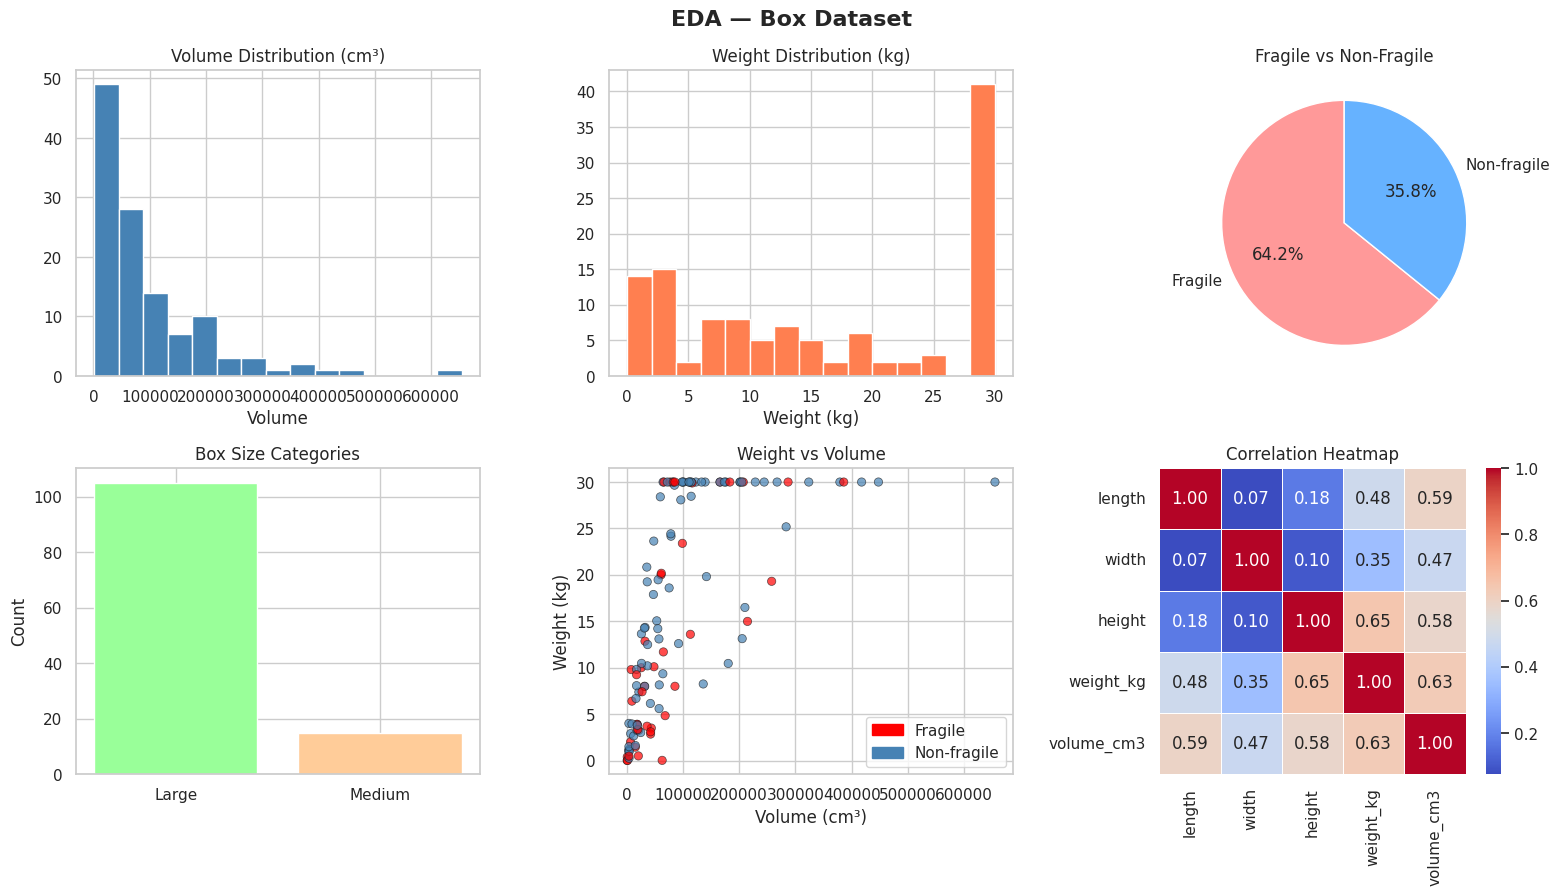

EDA plots saved ✅


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('EDA — Box Dataset', fontsize=16, fontweight='bold')

# Volume distribution
axes[0,0].hist(df['volume_cm3'], bins=15, color='steelblue', edgecolor='white')
axes[0,0].set_title('Volume Distribution (cm³)')
axes[0,0].set_xlabel('Volume')

# Weight distribution
axes[0,1].hist(df['weight_kg'], bins=15, color='coral', edgecolor='white')
axes[0,1].set_title('Weight Distribution (kg)')
axes[0,1].set_xlabel('Weight (kg)')

# Fragile vs Non-fragile
counts = df['fragile'].value_counts()
axes[0,2].pie(counts, labels=['Fragile','Non-fragile'], autopct='%1.1f%%',
              colors=['#ff9999','#66b2ff'], startangle=90)
axes[0,2].set_title('Fragile vs Non-Fragile')

# Size category bar chart
size_counts = df['size_category'].value_counts()
axes[1,0].bar(size_counts.index, size_counts.values,
              color=['#99ff99','#ffcc99','#ff9999'])
axes[1,0].set_title('Box Size Categories')
axes[1,0].set_ylabel('Count')

# Weight vs Volume scatter
colors = df['fragile'].map({True: 'red', False: 'steelblue'})
axes[1,1].scatter(df['volume_cm3'], df['weight_kg'], c=colors, alpha=0.7, edgecolors='k', linewidths=0.5)
axes[1,1].set_title('Weight vs Volume')
axes[1,1].set_xlabel('Volume (cm³)')
axes[1,1].set_ylabel('Weight (kg)')
red_patch = mpatches.Patch(color='red', label='Fragile')
blue_patch = mpatches.Patch(color='steelblue', label='Non-fragile')
axes[1,1].legend(handles=[red_patch, blue_patch])

# Dimension correlation heatmap
corr = df[['length','width','height','weight_kg','volume_cm3']].corr()
sns.heatmap(corr, ax=axes[1,2], annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
axes[1,2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA plots saved ✅')

## 7. Container Utilization Preview

In [8]:
total_box_volume = df['volume_cm3'].sum()
container_volume = container.volume
utilization = (total_box_volume / container_volume) * 100

print(f'Container volume      : {container_volume:,.0f} cm³  ({container_volume/1e6:.3f} m³)')
print(f'Total box volume      : {total_box_volume:,.0f} cm³  ({total_box_volume/1e6:.3f} m³)')
print(f'Raw utilization       : {utilization:.2f}%')
print(f'\n→ We have {len(boxes)} boxes to pack.')
print(f'→ Theoretical max utilization (ignoring gaps): {utilization:.1f}%')
print(f'→ Target after optimization: ≥ 75–80%')

Container volume      : 33,081,185 cm³  (33.081 m³)
Total box volume      : 11,587,778 cm³  (11.588 m³)
Raw utilization       : 35.03%

→ We have 120 boxes to pack.
→ Theoretical max utilization (ignoring gaps): 35.0%
→ Target after optimization: ≥ 75–80%


## 8. Export Preprocessed Data to a new file

In [9]:
df.to_csv('boxes_preprocessed.csv', index=False)
print('Saved boxes_preprocessed.csv ✅')
print(f'Final dataset shape: {df.shape}')
df.head()

Saved boxes_preprocessed.csv ✅
Final dataset shape: (120, 9)


,id,length,width,height,weight_kg,fragile,volume_cm3,density,size_category
0,1,62.0,17.0,60.0,0.020,True,63240.0,3.162555e-07,Large
1,2,15.0,12.0,6.0,0.015,True,1080.0,1.388889e-05,Medium
2,3,31.0,25.0,9.0,2.000,True,6975.0,2.867384e-04,Medium
3,4,61.0,43.0,8.0,0.500,True,20984.0,2.382768e-05,Large
4,5,58.0,39.0,38.0,8.000,True,85956.0,9.307087e-05,Large
